# Data preperation For the Fuel Cell

here data is prepared from the full set (1.8GB is too large to send). The data is sampled and saved into Pickle files so no large files have to be imported over and over again. Please note that the import of the csv has been deleted as it is not needed anymore.

### Small dataset:

In [121]:
# From the Start_V2 file:
""
"  This Code is created by Daan Schat - 5169801 - TU Delft Master Student SET"
"  for the Green Village energy hub project"
""

#Setting up the environment:
import matplotlib.pyplot as plt
import random
import os
import pandas as pd
import numpy as np
import chardet
#import matplotlib.image as mpimg # Used later to export to PNG)

#The following data is given to be directly from the database by Marijn (GV)
data = "SSS-Fuel-battery-dec-jan-SoC.csv"

# Detect data type (gave me problems before, so we just check to be sure)
with open(data, 'rb') as f:
    result = chardet.detect(f.read(10000))
print(result)
encoding = result['encoding']
print(f"Detected encoding: {encoding}")

#First the data is imported:
data = pd.read_csv(data, encoding=encoding) # UTF-16 was needed: otherwise the data had problems, as shown above
print(f"the data exists of the columns:\n", data.columns)

# Then the data is trimmed down to the timestamps we are interested in:
# Quick note: all data is shifted by 2 hours from the real time data in Grafana

data['time'] = pd.to_datetime(data['time'],format='ISO8601') # The time format gave me problems, so it is specified here.

# The following time stamps are testing times
start_date = '2024-08-05 00:00:00'
end_date = '2024-08-06 23:59:59'
start_date = pd.to_datetime(start_date).tz_localize('UTC')
end_date = pd.to_datetime(end_date).tz_localize('UTC')


# The following time stamps are the week of interest, not used in testing:
#start_date = '2024-08-05 00:00:00'
#end_date = '2024-08-11 23:59:59'

# We trimm the data to work with down
#data = data[(data['time'] >= start_date) & (data['time'] <= end_date)] 


# Make subsets of data to work with

grouped = data.groupby(['device_id', 'measurement_id'])

device_measurement_dict = {}

for (device, measurement), group in grouped:
    var_name = f"{device}_{measurement}".replace(" ", "_")
    globals()[var_name] = group
    device_measurement_dict[(device, measurement)] = group

# Now, display the names of all the new variables, so we can use them later
new_var_names = [f"{device}_{measurement}".replace(" ", "_") for device, measurement in device_measurement_dict.keys()]
print("Newly created variables:")
for var in new_var_names:
    print(var)

{'encoding': 'ascii', 'confidence': 1.0, 'language': ''}
Detected encoding: ascii
the data exists of the columns:
 Index(['name', 'time', 'application_id', 'device_id', 'measurement_id',
       'value_NoneType', 'value_float'],
      dtype='object')
Newly created variables:
Battery_State_Of_Charge
Pressure_Transmitter_State_Of_Charge


### Zerogaps:

In [102]:
def zerogapsv2(df):
    # Ensure the 'time' column exists
    # Convert 'time' column to datetime
# Ensure 'time' column is in datetime format
    df['time'] = pd.to_datetime(df['time']) 
    
    # Sort by time
    df = df.sort_values('time')
    df.set_index('time', inplace=True)

    # Generate a complete range of timestamps with 1-minute frequency
    full_time_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='1min')

    # Reindex the DataFrame to the full time range
    df = df.reindex(full_time_range)

    # Fill missing values with zeros for all columns (except index)
    df.fillna(0, inplace=True)

    # Reset the index to make 'time' a column again
    df.reset_index(inplace=True)
    df.rename(columns={'index': 'time'}, inplace=True)

    return df

# We can now use ChatGPT's function to fill in all missing datapoints:
#for var in new_var_names:
#    df = globals()[var]
#    globals()[var] = zerogapsv2(df)


def zerogaps_1_hour(df):
    # Ensure the 'time' column exists
    # Convert 'time' column to datetime
# Ensure 'time' column is in datetime format
    df['time'] = pd.to_datetime(df['time']) 
    
    # Sort by time
    df = df.sort_values('time')
    df.set_index('time', inplace=True)

    # Generate a complete range of timestamps with 1-minute frequency
    full_time_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='1hour')

    # Reindex the DataFrame to the full time range
    df = df.reindex(full_time_range)

    # Fill missing values with zeros for all columns (except index)
    df.fillna(0, inplace=True)

    # Reset the index to make 'time' a column again
    df.reset_index(inplace=True)
    df.rename(columns={'index': 'time'}, inplace=True)

    return df


def zerogaps_15_min(df):
    # Ensure the 'time' column exists
    # Convert 'time' column to datetime
# Ensure 'time' column is in datetime format
    df['time'] = pd.to_datetime(df['time']) 
    
    # Sort by time
    df = df.sort_values('time')
    df.set_index('time', inplace=True)

    # Generate a complete range of timestamps with 1-minute frequency
    full_time_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='15min')

    # Reindex the DataFrame to the full time range
    df = df.reindex(full_time_range)

    # Fill missing values with zeros for all columns (except index)
    df.fillna(0, inplace=True)

    # Reset the index to make 'time' a column again
    df.reset_index(inplace=True)
    df.rename(columns={'index': 'time'}, inplace=True)

    return df

for var in new_var_names:
    df = globals()[var]
    globals()[var] = zerogapsv2(df)



In [83]:
# Azadeh's code

def zerogaps_asfreq(df):
    df['time'] = pd.to_datetime(df['time'])  # Convert 'time' column to datetime
    df = df.sort_values('time')             # Sort by time
    df.set_index('time', inplace=True)      # Set 'time' as the index
    # Resample to 1-minute frequency and fill missing data with zeros
    df = df.asfreq('1min', fill_value=0)  
    df.reset_index(inplace=True)            # Reset the index
    return df
'-----'
def zerogaps_resample(df):
    df['time'] = pd.to_datetime(df['time'])
    df = df.sort_values('time').set_index('time')
    # Resample at 1-minute intervals and fill missing values
    df = df.resample('1min').sum().fillna(0)
    df.reset_index(inplace=True)
    return df
'-----'
def zerogaps_merge(df):
    df['time'] = pd.to_datetime(df['time'])
    df = df.sort_values('time')
    full_time_range = pd.DataFrame({'time': pd.date_range(start=df['time'].min(), end=df['time'].max(), freq='1min')})
    # Merge with the full time range and fill missing values with zeros
    df = full_time_range.merge(df, on='time', how='left').fillna(0)
    return df
'-----'

for var in new_var_names:
    df = globals()[var]
    globals()[var] = zerogaps_resample(df)

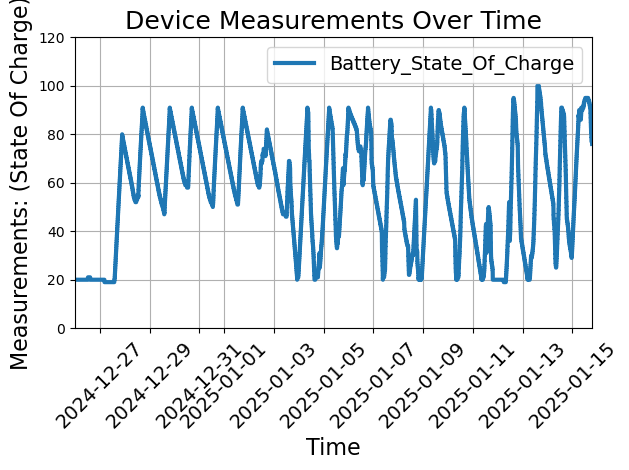

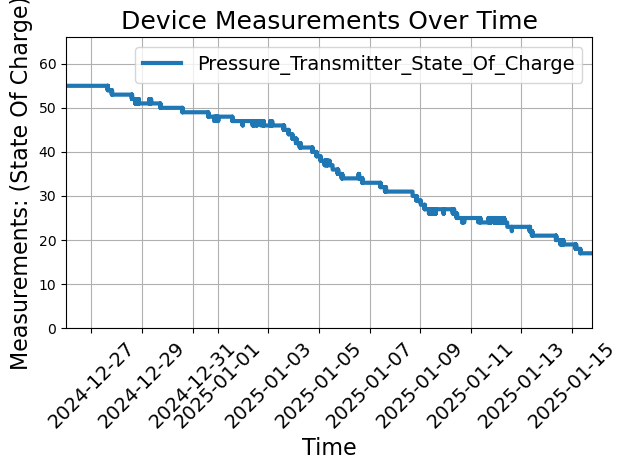

In [123]:
fplot('Battery_State_Of_Charge')
fplot('Pressure_Transmitter_State_Of_Charge')

In [2]:
# Doing the same for the bigger dataset:

# From the Start_V2 file:
""
"  This Code is created by Daan Schat - 5169801 - TU Delft Master Student SET"
"  for the Green Village energy hub project"
""

#Setting up the environment:
import matplotlib.pyplot as plt
import random
import os
import pandas as pd
import numpy as np
import chardet
#import matplotlib.image as mpimg # Used later to export to PNG)

#The following data is given to be directly from the database by Marijn (GV)
data = "SSS-Battery-dec-jan.csv" #"SSS-Fuel-dec-jan.csv"

# Detect data type (gave me problems before, so we just check to be sure)
with open(data, 'rb') as f:
    result = chardet.detect(f.read(10000))
print(result)
encoding = result['encoding']
print(f"Detected encoding: {encoding}")

#First the data is imported:
data = pd.read_csv(data, encoding=encoding) # UTF-16 was needed: otherwise the data had problems, as shown above
print(f"the data exists of the columns:\n", data.columns)

# Then the data is trimmed down to the timestamps we are interested in:
# Quick note: all data is shifted byf 2 hours from the real time data in Grafana

data['time'] = pd.to_datetime(data['time'],format='ISO8601') # The time format gave me problems, so it is specified here.

# The following time stamps are testing times
start_date = '2024-08-05 00:00:00'
end_date = '2024-08-06 23:59:59'
start_date = pd.to_datetime(start_date).tz_localize('UTC')
end_date = pd.to_datetime(end_date).tz_localize('UTC')


# The following time stamps are the week of interest, not used in testing:
#start_date = '2024-08-05 00:00:00'
#end_date = '2024-08-11 23:59:59'

# We trimm the data to work with down
#data = data[(data['time'] >= start_date) & (data['time'] <= end_date)] 


# Make subsets of data to work with

grouped = data.groupby(['device_id', 'measurement_id'])

device_measurement_dict = {}

for (device, measurement), group in grouped:
    var_name = f"{device}_{measurement}".replace(" ", "_")
    globals()[var_name] = group
    device_measurement_dict[(device, measurement)] = group

# Now, display the names of all the new variables, so we can use them later
new_var_names = [f"{device}_{measurement}".replace(" ", "_") for device, measurement in device_measurement_dict.keys()]
print("Newly created variables:")
for var in new_var_names:
    print(var)

{'encoding': 'UTF-16', 'confidence': 1.0, 'language': ''}
Detected encoding: UTF-16
the data exists of the columns:
 Index(['name', 'time', 'application_id', 'device_id', 'measurement_id',
       'value_NoneType', 'value_float'],
      dtype='object')
Newly created variables:
Battery_Inverter_AC_Out_Power


In [4]:
def zerogapsv3(df):
    df['time'] = pd.to_datetime(df['time'])
    df = df.sort_values('time').set_index('time')
    
    # Separate numeric columns and non-numeric columns
    numeric_cols = df.select_dtypes(include=['number']).columns
    non_numeric_cols = df.select_dtypes(exclude=['number']).columns
    
    # Resample only the numeric columns and fill missing values with zeros
    df_numeric = df[numeric_cols].resample('1min').mean().fillna(0)
    
    # Forward fill the non-numeric columns to preserve their original values
    df_non_numeric = df[non_numeric_cols].resample('1min').ffill()
    
    # Combine the numeric and non-numeric dataframes
    df_resampled = pd.concat([df_non_numeric, df_numeric], axis=1)
    
    # Reset index to restore 'time' as a column
    df_resampled.reset_index(inplace=True)
    
    return df_resampled

for var in new_var_names:
    df = globals()[var]
    globals()[var] = zerogapsv3(df)

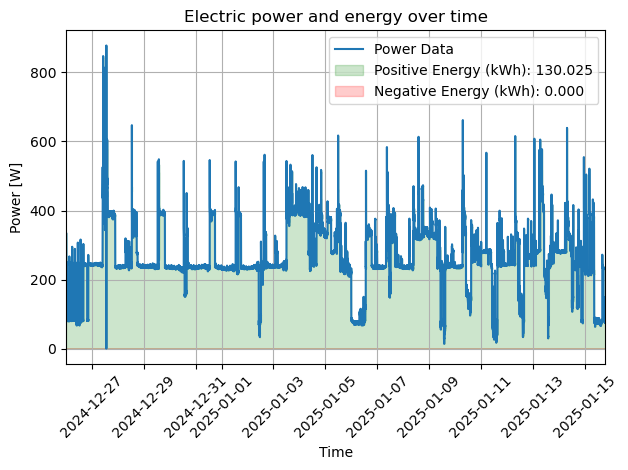

(130.0250821706374, 130.0250821706374, 0.0)

In [12]:
integrate_hr('Battery_Inverter_AC_Out_Power')


In [8]:
# Setting up plotting layout
figdim=(6.4, 4.8)
title_fontsize  = 18
label_fontsize  = 16
tick_fontsize   = 14
legend_fontsize = 14

# The following fucntions plot figures on the data and/or do some calculations.
# The functions just simply take the new pandas dataframes by their string name: E.g. 'Battery_Current'

# The fplot function simply plots a feature over time (and can take multiple features to be plotted into one figure)
def fplot(*vars):
    minval = maxval = 0
    measurement_types = set()
    plt.figure(figsize=figdim)
    for var in vars:
        if var in globals():
            data = globals()[var] # Needed to recall the data from their string name
            device_measurement_label = f"{data['device_id'].iloc[0]} - {data['measurement_id'].iloc[0]}"
            plt.plot(data['time'], data['value_float'], marker='', linestyle='-',linewidth = 3, label=var,)
            measurement_types.add(data['measurement_id'].iloc[0])

            #Determines size needed of the canvas (surely could be improved)
            if minval > min(data['value_float']):
                minval = min(data['value_float'])
            if maxval < max(data['value_float']):
                maxval = max(data['value_float'])
        else:
            print(f"Variable '{var}' not found!")

    # Fixes labeling for multiple features to be plotted in one figure
    if len(measurement_types) == 1:
        plt.ylabel(f"Measurements: ({measurement_types.pop()})", fontsize=label_fontsize)
    else:
        plt.ylabel(f"Measurements: ({', '.join(sorted(measurement_types))})", fontsize=label_fontsize)

    # Plotting settings:
    plt.xlabel('Time', fontsize=label_fontsize)
 #  plt.ylabel(f'Value {data['measurement_id']}', fontsize=label_fontsize)
    plt.xlim(min(data['time']), max(data['time']))
    plt.ylim(minval*1.2, maxval*1.2)
    plt.title('Device Measurements Over Time',fontsize=title_fontsize)
    plt.xticks(rotation=45, fontsize=tick_fontsize)
    plt.tight_layout()
    plt.legend(fontsize=legend_fontsize)
    plt.grid(True)
    plt.show()

# These functions handle integration (area under curve) For energy (W) to (kWh) and H2 flow (NL/h) to (kg & kWh)
def integrate(var):
    if var in globals():
        data = globals()[var]
        time = data['time']
        values = data['value_float']
        time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)
        integral = np.trapz(values, time_numeric)
    else:
        print(f"Variable '{var}' not found!")

    plt.figure(figsize=figdim)
    plt.plot(time, values, label='Data')
    plt.fill_between(time, values, alpha=0.2, label=f'Integrated Area: {integral_value}')
    plt.xlabel('Time')
    plt.ylabel('Value')
    plt.xlim(min(time),max(time))
    plt.title('Integrated data')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return integral


# Called upon, this function gives a plot with integrated results of power, and gives the energy content (Pos,Neg, and cumulative)
def integrate_hr(var):
    if var in globals():
        data = globals()[var]
        time = data['time']
        values = data['value_float']
        time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)
        
        # We seperate positive and negative data in case power can be negative and positive (Battery)
        positive_values = np.where(values > 0, values, 0)
        negative_values = np.where(values < 0, values, 0)
        kWh_pos = np.trapz(positive_values, time_numeric)/3600000 # Perform integration for positive values
        kWh_neg = np.trapz(negative_values, time_numeric)/3600000 # Perform integration for negative values
        joules = np.trapz(values, time_numeric)
        energy_kWh = joules / 3600000
    else:
        print(f"Variable '{var}' not found!")  

    plt.figure(figsize=figdim)
    plt.plot(time, values, label='Power Data')
    plt.fill_between(time, positive_values, alpha=0.2, label=f'Positive Energy (kWh): {kWh_pos:.3f}', color='green')
    plt.fill_between(time, negative_values, alpha=0.2, label=f'Negative Energy (kWh): {kWh_neg:.3f}', color='red')
    plt.xlabel('Time')
    plt.ylabel('Power [W]')
    plt.xlim(min(time),max(time))
    plt.title('Electric power and energy over time')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return energy_kWh, kWh_pos, kWh_neg


def integrate_h2(var):
    if var in globals():
        data = globals()[var]
        time = data['time']
        values = data['value_float']
        time_numeric = (time - time.iloc[0]).dt.total_seconds().astype(int)
        positive_values = np.where(values > 0, values, 0)
        H2pos = np.trapz(values, time_numeric) # Perform integration
    else:
        print(f"Variable '{var}' not found!")  
    
    H2Prod = H2Density*H2pos/(3600*1000) # H2 flow to kg
    EnergyH2 = LHV_H2*H2Prod/(3600*1000) # H2 flow to kWh(chem) (of H2)
    plt.figure(figsize=figdim)
    plt.plot(time, values, label='Hydrogen production')
    plt.fill_between(time, positive_values, alpha=0.2, label=f'Hydrogen produced: {H2Prod:.3f} kg', color='blue')
    plt.fill_between(time, positive_values, alpha=0.2, label=f'Energy content: {EnergyH2:.3f} kWh', color='blue')

    plt.xlabel('Time')
    plt.ylabel('Hydrogen Flow [NL/h]')
    plt.xlim(min(time),max(time))
    plt.title('Hydrogen production over time')
    plt.legend()
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    return H2Prod

Now that the data from the CSV is imported, we will save each dataframe in pickle files:

In [14]:
subfolder = "All dataframes/dataframes-fuel-cell"
os.makedirs(subfolder, exist_ok=True)

# Save all dataframes dynamically
for var_name in new_var_names:
    globals()[var_name].to_pickle(os.path.join(subfolder, f"{var_name}.pkl"))


### Solar irradiance data:

{'encoding': 'UTF-16', 'confidence': 1.0, 'language': ''}
Detected encoding: UTF-16
the data exists of the columns:
 Index(['name', 'time', 'measurement_id', 'value_float', 'value_int', 'unit'], dtype='object')
Resampled the data with original file structure


### Full dataset:

{'encoding': 'UTF-16', 'confidence': 1.0, 'language': ''}
Detected encoding: UTF-16
the data exists of the columns:
 Index(['time', 'value_float', 'device_id', 'measurement_id', 'application_id',
       'name'],
      dtype='object')
Newly created variables:
Battery_Current
Battery_Power
Battery_State_Of_Charge
Battery_Temperature
Battery_Voltage
Battery_Inverter_AC_In_Power
Battery_Inverter_AC_Out_Power
Battery_Inverter_Grid_Setpoint
Compressor_Anode_Dewpoint
Compressor_Anode_Heat_Tracing_Control_Signal
Compressor_Anode_Heat_Tracing_Temperature
Compressor_Anode_Pressure
Compressor_Anode_Relative_Humidity
Compressor_Anode_Temperature
Compressor_Cathode_Pressure
Compressor_Compressor_Coolant_Flow
Compressor_Compressor_Coolant_Temperature_In
Compressor_Compressor_Coolant_Temperature_Out
Compressor_Compressor_Cooling_Notch_Ball_Valve_Control_Signal
Compressor_Compressor_Cooling_Pump_Control_Signal
Compressor_Current_State
Compressor_Dryer_Pressure
Compressor_Hydraulic_Pressure
Compressor_

15min sampling dataset:

In [21]:
# From the Start_V2 file:
""
"  This Code is created by Daan Schat - 5169801 - TU Delft Master Student SET"
"  for the Green Village energy hub project"
""

#Setting up the environment:
import matplotlib.pyplot as plt
import random
import os
import pandas as pd
import numpy as np
import chardet
#import matplotlib.image as mpimg # Used later to export to PNG)

#The following data is given to be directly from the database by Marijn (GV)
data = "SSS-August-full-set.csv"
subfolder = "All dataframes/dataframes-full-set-15-min"


# Detect data type (gave me problems before, so we just check to be sure)
with open(data, 'rb') as f:
    result = chardet.detect(f.read(10000))
print(result)
encoding = result['encoding']
print(f"Detected encoding: {encoding}")

#First the data is imported:
data = pd.read_csv(data, encoding='UTF-16') # UTF-16 was needed: otherwise the data had problems, as shown above
print(f"the data exists of the columns:\n", data.columns)

# Then the data is trimmed down to the timestamps we are interested in:
# Quick note: all data is shifted by 2 hours from the real time data in Grafana

data['time'] = pd.to_datetime(data['time'],format='ISO8601') # The time format gave me problems, so it is specified here.

# The following time stamps are testing times
start_date = '2024-08-01 00:00:00'
end_date = '2024-08-31 23:59:59'
start_date = pd.to_datetime(start_date).tz_localize('UTC')
end_date = pd.to_datetime(end_date).tz_localize('UTC')


# The following time stamps are the week of interest, not used in testing:
#start_date = '2024-08-05 00:00:00'
#end_date = '2024-08-11 23:59:59'

# We trimm the data to work with down
data = data[(data['time'] >= start_date) & (data['time'] <= end_date)] 


# Make subsets of data to work with

grouped = data.groupby(['device_id', 'measurement_id'])

device_measurement_dict = {}

for (device, measurement), group in grouped:
    var_name = f"{device}_{measurement}".replace(" ", "_")
    globals()[var_name] = group
    device_measurement_dict[(device, measurement)] = group

# Now, display the names of all the new variables, so we can use them later
new_var_names = [f"{device}_{measurement}".replace(" ", "_") for device, measurement in device_measurement_dict.keys()]
print("Newly created variables:")
for var in new_var_names:
    print(var)

for var in new_var_names:
    df = globals()[var]
    globals()[var] = zerogaps_15_min(df)




os.makedirs(subfolder, exist_ok=True)

# Save all dataframes dynamically
for var_name in new_var_names:
    globals()[var_name].to_pickle(os.path.join(subfolder, f"{var_name}.pkl"))


{'encoding': 'UTF-16', 'confidence': 1.0, 'language': ''}
Detected encoding: UTF-16
the data exists of the columns:
 Index(['time', 'value_float', 'device_id', 'measurement_id', 'application_id',
       'name'],
      dtype='object')
Newly created variables:
Battery_Current
Battery_Power
Battery_State_Of_Charge
Battery_Temperature
Battery_Voltage
Battery_Inverter_AC_In_Power
Battery_Inverter_AC_Out_Power
Battery_Inverter_Grid_Setpoint
Compressor_Anode_Dewpoint
Compressor_Anode_Heat_Tracing_Control_Signal
Compressor_Anode_Heat_Tracing_Temperature
Compressor_Anode_Pressure
Compressor_Anode_Relative_Humidity
Compressor_Anode_Temperature
Compressor_Cathode_Pressure
Compressor_Compressor_Coolant_Flow
Compressor_Compressor_Coolant_Temperature_In
Compressor_Compressor_Coolant_Temperature_Out
Compressor_Compressor_Cooling_Notch_Ball_Valve_Control_Signal
Compressor_Compressor_Cooling_Pump_Control_Signal
Compressor_Current_State
Compressor_Dryer_Pressure
Compressor_Hydraulic_Pressure
Compressor_

### Validation set (2 days)

In [10]:
# From the Start_V2 file:
""
"  This Code is created by Daan Schat - 5169801 - TU Delft Master Student SET"
"  for the Green Village energy hub project"
""

#Setting up the environment:
import matplotlib.pyplot as plt
import random
import os
import pandas as pd
import numpy as np
import chardet
#import matplotlib.image as mpimg # Used later to export to PNG)

#The following data is given to be directly from the database by Marijn (GV)
data = "SSS-August-full-set.csv"

# Detect data type (gave me problems before, so we just check to be sure)
with open(data, 'rb') as f:
    result = chardet.detect(f.read(10000))
print(result)
encoding = result['encoding']
print(f"Detected encoding: {encoding}")

#First the data is imported:
data = pd.read_csv(data, encoding='UTF-16') # UTF-16 was needed: otherwise the data had problems, as shown above
print(f"the data exists of the columns:\n", data.columns)

# Then the data is trimmed down to the timestamps we are interested in:
# Quick note: all data is shifted by 2 hours from the real time data in Grafana

data['time'] = pd.to_datetime(data['time'],format='ISO8601') # The time format gave me problems, so it is specified here.

# The following time stamps are testing times
start_date = '2024-08-07 00:00:00'
end_date = '2024-08-08 23:59:59'
start_date = pd.to_datetime(start_date).tz_localize('UTC')
end_date = pd.to_datetime(end_date).tz_localize('UTC')


# The following time stamps are the week of interest, not used in testing:
#start_date = '2024-08-05 00:00:00'
#end_date = '2024-08-11 23:59:59'

# We trimm the data to work with down
data = data[(data['time'] >= start_date) & (data['time'] <= end_date)] 


# Make subsets of data to work with

grouped = data.groupby(['device_id', 'measurement_id'])

device_measurement_dict = {}

for (device, measurement), group in grouped:
    var_name = f"{device}_{measurement}".replace(" ", "_")
    globals()[var_name] = group
    device_measurement_dict[(device, measurement)] = group

# Now, display the names of all the new variables, so we can use them later
new_var_names = [f"{device}_{measurement}".replace(" ", "_") for device, measurement in device_measurement_dict.keys()]
print("Newly created variables:")
for var in new_var_names:
    df = globals()[var]
    globals()[var] = zerogapsv2(df)
    print(var)



subfolder = "dataframes-1-min-2"

os.makedirs(subfolder, exist_ok=True)

# Save all dataframes dynamically
for var_name in new_var_names:
    globals()[var_name].to_pickle(os.path.join(subfolder, f"{var_name}.pkl"))


{'encoding': 'UTF-16', 'confidence': 1.0, 'language': ''}
Detected encoding: UTF-16
the data exists of the columns:
 Index(['time', 'value_float', 'device_id', 'measurement_id', 'application_id',
       'name'],
      dtype='object')
Newly created variables:
Battery_Current
Battery_Power
Battery_State_Of_Charge
Battery_Temperature
Battery_Voltage
Battery_Inverter_AC_In_Power
Battery_Inverter_AC_Out_Power
Battery_Inverter_Grid_Setpoint
Compressor_Anode_Dewpoint
Compressor_Anode_Heat_Tracing_Control_Signal
Compressor_Anode_Heat_Tracing_Temperature
Compressor_Anode_Pressure
Compressor_Anode_Relative_Humidity
Compressor_Anode_Temperature
Compressor_Cathode_Pressure
Compressor_Compressor_Coolant_Flow
Compressor_Compressor_Coolant_Temperature_In
Compressor_Compressor_Coolant_Temperature_Out
Compressor_Compressor_Cooling_Notch_Ball_Valve_Control_Signal
Compressor_Compressor_Cooling_Pump_Control_Signal
Compressor_Current_State
Compressor_Dryer_Pressure
Compressor_Hydraulic_Pressure
Compressor_